# Eksploracyjna analiza danych (EDA)


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', palette='muted')

df = pd.read_csv('../dataset/transformacja_intermediate.csv')
weekly_sales = pd.read_csv('../dataset/weekly_sales_by_item.csv')


In [10]:

print('Transform dataset shape:', df.shape)
print('Weekly dataset shape:', weekly_sales.shape)

print('\nTransform dataset columns:')
print(df.columns.tolist())

print('\nTransform dataset head:')
df.head()

print('\nWeekly dataset head:')
weekly_sales.head()


Transform dataset shape: (9529, 14)
Weekly dataset shape: (424, 7)

Transform dataset columns:
['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Year', 'Month', 'Day', 'Weekday', 'week_start', 'YearWeek']

Transform dataset head:

Weekly dataset head:


,YearWeek,Item,week_start,weekly_quantity,weekly_revenue,transaction_count,avg_price_per_unit
0,2022-52,Cake,2022-12-26,14.0,42.0,4,3.0
1,2022-52,Coffee,2022-12-26,14.0,28.0,5,2.0
2,2022-52,Cookie,2022-12-26,4.0,4.0,1,1.0
3,2022-52,Juice,2022-12-26,6.0,18.0,2,3.0
4,2022-52,Salad,2022-12-26,4.0,20.0,2,5.0


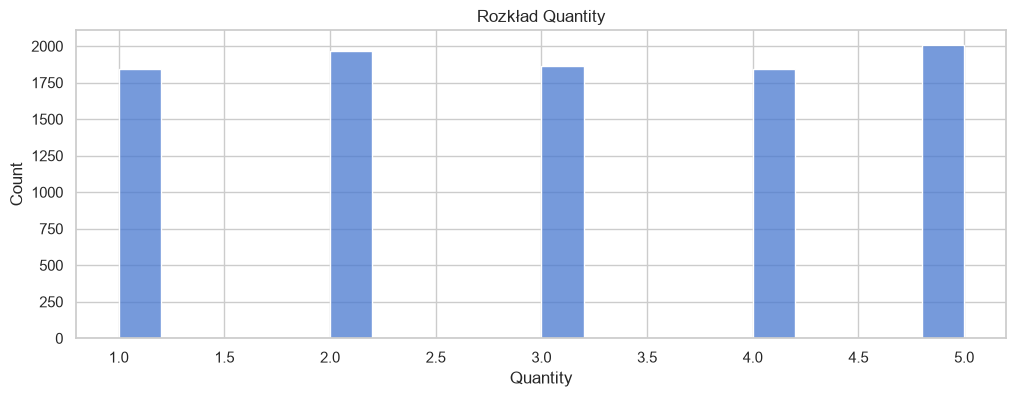

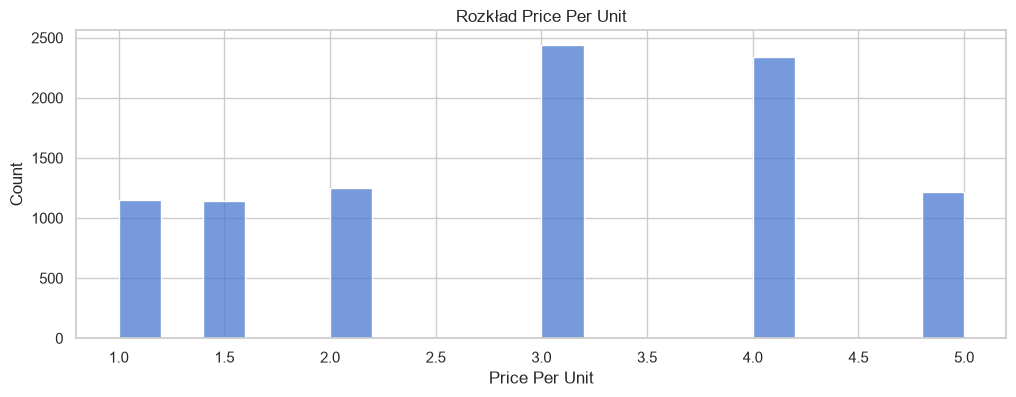

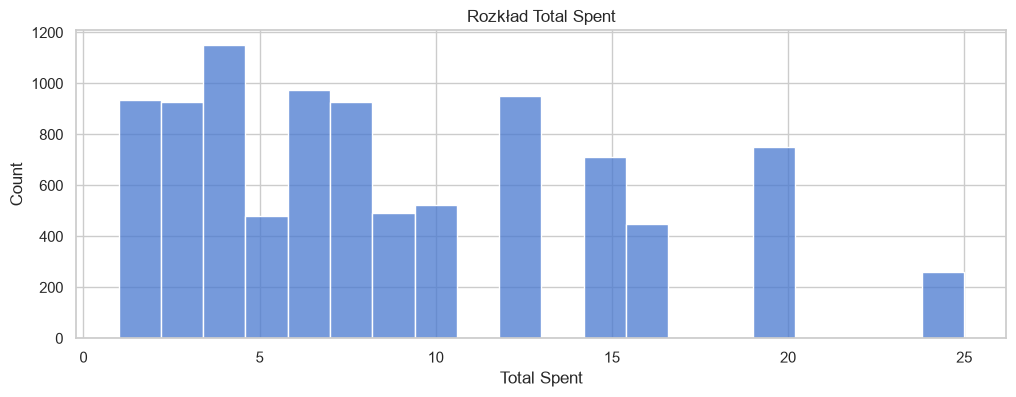

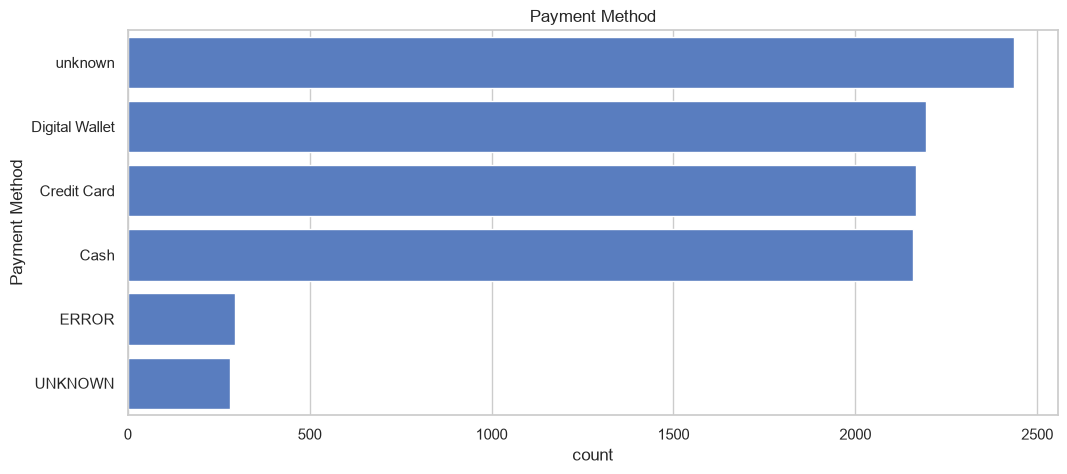

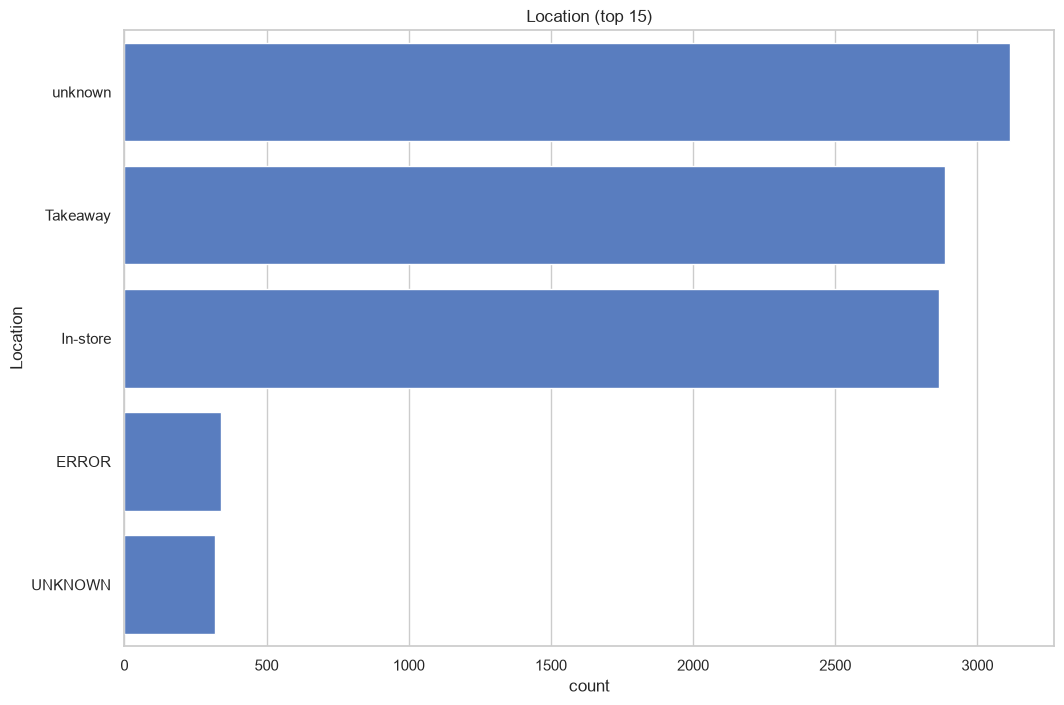

In [ ]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
weekly_sales['week_start'] = pd.to_datetime(weekly_sales['week_start'], errors='coerce')

plt.figure(figsize=(12, 4))
sns.histplot(df['Quantity'].dropna(), bins=20)
plt.title('Rozkład Quantity')
plt.show()

plt.figure(figsize=(12, 4))
sns.histplot(df['Price Per Unit'].dropna(), bins=20)
plt.title('Rozkład Price Per Unit')
plt.show()

plt.figure(figsize=(12, 4))
sns.histplot(df['Total Spent'].dropna(), bins=20)
plt.title('Rozkład Total Spent')
plt.show()

plt.figure(figsize=(12, 5))
sns.countplot(data=df, y='Payment Method', order=df['Payment Method'].value_counts().index)
plt.title('Payment Method')
plt.show()

plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='Location', order=df['Location'].value_counts().index[:15])
plt.title('Location (top 15)')
plt.show()


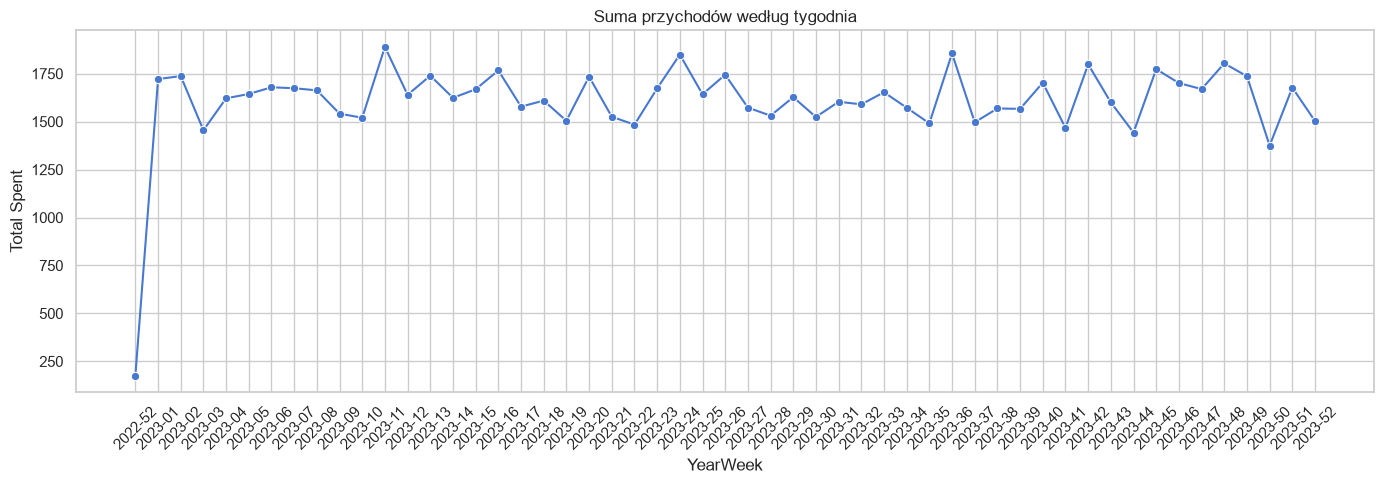

Najpopularniejsze produkty w danych transformacyjnych:
Item
Cake        1316
Smoothie    1264
Coffee      1246
Salad       1216
Cookie      1150
Tea         1141
Juice       1124
Sandwich    1072
Name: count, dtype: int64

Top 10 produktów według łącznego przychodu w danych tygodniowych:
Item
Salad       18270.0
Smoothie    15460.0
Sandwich    13080.0
Cake        12000.0
Juice       10053.0
Coffee       7554.0
Tea          5161.5
Cookie       3431.0
Name: weekly_revenue, dtype: float64


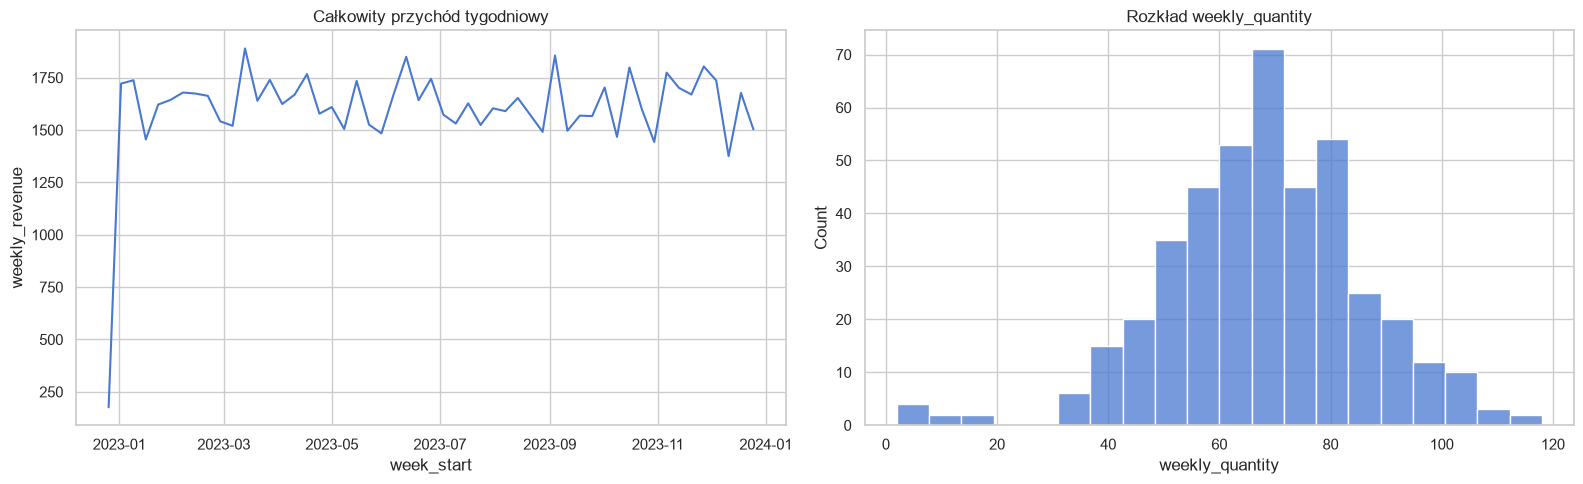

In [ ]:
weekly_total = df.groupby('YearWeek', as_index=False)['Total Spent'].sum().sort_values('YearWeek')

plt.figure(figsize=(14, 5))
sns.lineplot(data=weekly_total, x='YearWeek', y='Total Spent', marker='o')
plt.xticks(rotation=45)
plt.title('Suma przychodów według tygodnia')
plt.tight_layout()
plt.show()

print('Najpopularniejsze produkty w danych transformacyjnych:')
print(df['Item'].value_counts().head(10))

print('\nTop 10 produktów według łącznego przychodu w danych tygodniowych:')
print(weekly_sales.groupby('Item')['weekly_revenue'].sum().nlargest(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=weekly_sales.groupby('week_start', as_index=False)['weekly_revenue'].sum(), x='week_start', y='weekly_revenue', ax=axes[0])
axes[0].set_title('Całkowity przychód tygodniowy')
sns.histplot(weekly_sales['weekly_quantity'].dropna(), bins=20, ax=axes[1])
axes[1].set_title('Rozkład weekly_quantity')
plt.tight_layout()
plt.show()
